<a href="https://colab.research.google.com/github/Khadee-moh/MML-SDG2-ZERO-HUNGER/blob/main/machine_learning_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pandas scikit-learn matplotlib seaborn


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving csv.zip to csv.zip


In [ ]:
import pandas as pd
import zipfile

# Specify the name of the zip file
zip_file_name = "csv.zip"

# Get the list of files in the zip archive
with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    file_list = zip_ref.namelist()

# Print the list of files to help the user choose
print("Files in the zip archive:", file_list)

# Specify the name of the file you want to read from the zip
# Replace 'adm_crop_data_raw_AO.csv' with the actual filename you need
file_to_read = 'adm_crop_data_raw_AO.csv'

# Read the specified CSV file from the zip archive into a DataFrame
try:
    df = pd.read_csv(zip_file_name + '/' + file_to_read)
    print("\nDataFrame head:")
    display(df.head())
except KeyError:
    print(f"Error: File '{file_to_read}' not found in the zip archive.")
except Exception as e:
    print(f"An error occurred: {e}")

Files in the zip archive: ['adm_crop_data_raw_AO.csv', 'adm_crop_data_raw_BF.csv', 'adm_crop_data_raw_BI.csv', 'adm_crop_data_raw_BJ.csv', 'adm_crop_data_raw_CD.csv', 'adm_crop_data_raw_CF.csv', 'adm_crop_data_raw_CM.csv', 'adm_crop_data_raw_ET.csv', 'adm_crop_data_raw_GH.csv', 'adm_crop_data_raw_GN.csv', 'adm_crop_data_raw_KE.csv', 'adm_crop_data_raw_LR.csv', 'adm_crop_data_raw_LS.csv', 'adm_crop_data_raw_MG.csv', 'adm_crop_data_raw_ML.csv', 'adm_crop_data_raw_MR.csv', 'adm_crop_data_raw_MW.csv', 'adm_crop_data_raw_MZ.csv', 'adm_crop_data_raw_NE.csv', 'adm_crop_data_raw_NG.csv', 'adm_crop_data_raw_RW.csv', 'adm_crop_data_raw_SDSS.csv', 'adm_crop_data_raw_SL.csv', 'adm_crop_data_raw_SN.csv', 'adm_crop_data_raw_SO.csv', 'adm_crop_data_raw_TD.csv', 'adm_crop_data_raw_TG.csv', 'adm_crop_data_raw_TZ.csv', 'adm_crop_data_raw_UG.csv', 'adm_crop_data_raw_ZA.csv', 'adm_crop_data_raw_ZM.csv', 'adm_crop_data_raw_ZW.csv']
An error occurred: [Errno 20] Not a directory: 'csv.zip/adm_crop_data_raw_A

In [ ]:
# SDG2_Maize_Yield_Prediction - Colab-ready script
# > Run in Google Colab (or locally). This script:
#   - downloads open datasets (Our World in Data / FAO / World Bank)
#   - builds features, trains RandomForest regression
#   - outputs evaluation metrics, plots, saved model + artifacts

# 0) Install / import
!pip install --quiet joblib scikit-learn matplotlib seaborn pandas xgboost --upgrade

import os
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import joblib
import requests

# Create artifact directories
os.makedirs("models", exist_ok=True)
os.makedirs("plots", exist_ok=True)
os.makedirs("data", exist_ok=True)
os.makedirs("report", exist_ok=True)

# 1) Download datasets (Our World in Data / FAO / World Bank)
# NOTE: OWID grapher endpoints usually accept '.csv' at the end of the grapher path.
# If a URL changes, adjust; these endpoints are commonly stable.

# Maize yields (tonnes/hectare) - Our World in Data "maize-yields" grapher
owid_maize_url = "https://ourworldindata.org/grapher/maize-yields.csv"
r = requests.get(owid_maize_url)
open("data/maize_yields_owid.csv", "wb").write(r.content)
maize_df = pd.read_csv("data/maize_yields_owid.csv")
print("maize_df:", maize_df.shape)

# Fertilizer use per hectare (OWID processed) - fertilizer use per hectare of cropland
owid_fert_url = "https://ourworldindata.org/grapher/fertilizer-use-per-hectare-of-cropland.csv"
r = requests.get(owid_fert_url)
open("data/fertilizer_per_ha.csv", "wb").write(r.content)
fert_df = pd.read_csv("data/fertilizer_per_ha.csv")
print("fert_df:", fert_df.shape)

# World Bank cereal yield indicator (kg per hectare) for cross-check/extra feature
wb_cereal_url = "https://api.worldbank.org/v2/en/indicator/AG.YLD.CREL.KG?downloadformat=csv"
# World Bank download returns a zipped CSV set; read via requests then handle manually is messy.
# Simpler: use OWID cereal yield grapher if available, or leave WB secondary.
# For reproducibility we will rely on OWID + FAO as primary numerical sources.

# 2) Quick preview & restrict columns (OWID format: country, year, value)
maize_df = maize_df.rename(columns={"Entity":"country","Year":"year","maize_yields":"value"}).loc[:, ["country","Year","Year","Year"]].head(1)
# NOTE: OWID CSV column names are sometimes 'Entity','Year','Value' or similar. Let's reload robustly:
maize_df = pd.read_csv("data/maize_yields_owid.csv")
print("Columns (maize):", maize_df.columns.tolist())
# OWID typical columns: entity, code, year, value. Ensure standardized col names:
maize_df.columns = [c.lower() for c in maize_df.columns]
# find the numeric column holding yield values
yield_col = [c for c in maize_df.columns if c not in ("entity","country","year","code","name")][-1]
print("Detected yield_col:", yield_col)
maize_df = maize_df.rename(columns={"entity":"country","year":"year", yield_col:"maize_yield_t_ha"})
maize_df = maize_df[["country","year","maize_yield_t_ha"]].dropna(subset=["maize_yield_t_ha"])
maize_df.head()

# Fertilizer
fert_df.columns = [c.lower() for c in fert_df.columns]
fert_val_col = [c for c in fert_df.columns if c not in ("entity","year","country","code","name")][-1]
fert_df = fert_df.rename(columns={"entity":"country","year":"year", fert_val_col:"fert_kg_per_ha"})
fert_df = fert_df[["country","year","fert_kg_per_ha"]]
fert_df.head()

# 3) Merge into a country-year table (inner join on country+year)
df = pd.merge(maize_df, fert_df, on=["country","year"], how="left")
print("Merged initial df:", df.shape)

# 4) Feature engineering - add lag of maize yield (previous year) where available
df = df.sort_values(["country","year"])
df["maize_yield_prev_t_ha"] = df.groupby("country")["maize_yield_t_ha"].shift(1)

# Optional: add GDP per capita and rural pop pct from OWID (common OWID datasets)
# Download GDP per capita (USD, constant) and rural population share
gdp_url = "https://ourworldindata.org/grapher/gdp-per-capita-maddison.csv" # placeholder - adjust if necessary
# For reliability, we will use built-in OWID indicators that are stable:
gdp_ppp_url = "https://ourworldindata.org/grapher/gdp-per-capita.csv"
ruralpop_url = "https://ourworldindata.org/grapher/percentage-of-population-living-in-rural-areas.csv"
# Attempt to fetch both (these might have different names; handle errors gracefully)
for url, fname in [(gdp_ppp_url, "data/gdp_per_capita.csv"), (ruralpop_url, "data/rural_pct.csv")]:
    try:
        r = requests.get(url)
        open(fname, "wb").write(r.content)
        print("Downloaded:", fname)
    except Exception as e:
        print("Could not download", url, ":", e)

# Load if present and merge
if os.path.exists("data/gdp_per_capita.csv"):
    gdp = pd.read_csv("data/gdp_per_capita.csv")
    gdp.columns = [c.lower() for c in gdp.columns]
    valcol = [c for c in gdp.columns if c not in ("entity","year","code","name")][-1]
    gdp = gdp.rename(columns={"entity":"country","year":"year", valcol:"gdp_per_capita"})
    gdp = gdp[["country","year","gdp_per_capita"]]
    df = df.merge(gdp, on=["country","year"], how="left")

if os.path.exists("data/rural_pct.csv"):
    rp = pd.read_csv("data/rural_pct.csv")
    rp.columns = [c.lower() for c in rp.columns]
    valcol = [c for c in rp.columns if c not in ("entity","year","code","name")][-1]
    rp = rp.rename(columns={"entity":"country","year":"year", valcol:"rural_pct"})
    rp = rp[["country","year","rural_pct"]]
    df = df.merge(rp, on=["country","year"], how="left")

print("After adding socioeconomics:", df.shape)
df.head()

# 5) Preprocessing: Impute, drop rows with missing target, create final X/y
df = df.dropna(subset=["maize_yield_t_ha"])  # we must have target
feature_cols = ["fert_kg_per_ha", "maize_yield_prev_t_ha", "gdp_per_capita", "rural_pct"]
# Keep only numeric features present
feature_cols = [c for c in feature_cols if c in df.columns]
X = df[feature_cols].copy()
y = df["maize_yield_t_ha"].astype(float).copy()

# Simple imputation
imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

# Optional scaling (not necessary for tree models but useful if you add MLP)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_imputed), columns=X_imputed.columns, index=X_imputed.index)

# 6) Train/test split (country-year data -> random split; for time series use time-aware split)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.15, random_state=42)

# Baseline: Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("LinearReg MAE:", mean_absolute_error(y_test, y_pred_lr))

# RandomForest (default) and quick RandomizedSearch for better hyperparams
rf = RandomForestRegressor(random_state=42)
param_dist = {
    "n_estimators":[100,200,400],
    "max_depth":[6,10,20,None],
    "min_samples_leaf":[1,2,4],
    "max_features":["sqrt","auto","log2"]
}
cv = KFold(n_splits=3, shuffle=True, random_state=42)
rs = RandomizedSearchCV(rf, param_distributions=param_dist, n_iter=12, cv=cv, scoring="neg_mean_absolute_error", random_state=42, n_jobs=-1, verbose=1)
rs.fit(X_train, y_train)
print("Best params:", rs.best_params_)
best_rf = rs.best_estimator_

# Evaluate on test
y_pred = best_rf.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)
print(f"RandomForest test MAE: {mae:.3f}, RMSE: {rmse:.3f}, R2: {r2:.3f}")

# Save model + preprocessing objects
joblib.dump(best_rf, "models/best_model_rf.joblib")
joblib.dump(imputer, "models/imputer.joblib")
joblib.dump(scaler, "models/scaler.joblib")

# 7) Plots: predicted vs actual, residuals, feature importance
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual maize yield (t/ha)")
plt.ylabel("Predicted maize yield (t/ha)")
plt.title("Predicted vs Actual - RandomForest")
plt.savefig("plots/pred_vs_actual.png", bbox_inches="tight")
plt.show()

residuals = y_test - y_pred
plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True)
plt.xlabel("Residuals (actual - predicted)")
plt.title("Residuals distribution")
plt.savefig("plots/residuals_hist.png", bbox_inches="tight")
plt.show()

# Feature importance (mean decrease impurity)
fi = pd.Series(best_rf.feature_importances_, index=X_scaled.columns).sort_values(ascending=False)
plt.figure(figsize=(6,4))
fi.plot(kind="bar")
plt.title("Feature importance (RandomForest)")
plt.ylabel("Importance")
plt.savefig("plots/feature_importance.png", bbox_inches="tight")
plt.show()

# 8) Save a small sample predictions CSV for demo
pred_df = pd.DataFrame({
    "country": df.loc[X_test.index, "country"],
    "year": df.loc[X_test.index, "year"],
    "actual_yield_t_ha": y_test,
    "predicted_yield_t_ha": y_pred
}).reset_index(drop=True)
pred_df.to_csv("data/predictions_sample.csv", index=False)

print("Artifacts saved under models/, plots/, data/.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 78.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 96.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 95.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 MB 7.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
dask-cudf-cu12 25.6.0 requires pandas<2.2.4dev0,>=2.0, but you have pandas 2.3.3 which is incompatible.
cudf-cu12 25.6.0 requires pandas<2.2.4dev0,>=2.0, but you have pandas 2.3.3 which is incompatible.
maize_df: (12229, 4)
fert_df: (12259, 4)


KeyError: "['Year'] not in index"

In [ ]:
maize_df = maize_df.rename(columns={"Entity": "country", "year": "year", "maize_yields": "value"})[["country", "year", "value"]]


KeyError: "['year', 'value'] not in index"

In [ ]:
maize_df.columns.tolist()



['Entity', 'Code', 'Year', 'Maize yield']

In [ ]:
# Clean and select relevant columns
maize_df = maize_df.rename(columns={
    "Entity": "country",
    "Year": "year",
    "Maize yield": "yield"
})[["country", "year", "yield"]]

# Quick preview
maize_df.head()



,country,year,yield
0,Afghanistan,1961,1.4000
1,Afghanistan,1962,1.4000
2,Afghanistan,1963,1.4260
3,Afghanistan,1964,1.4257
4,Afghanistan,1965,1.4400


In [ ]:
# Filter only Nigeria data
maize_df = maize_df[maize_df["country"] == "Nigeria"]

# Check the result
maize_df.head(), maize_df.shape


(      country  year   yield
 7828  Nigeria  1961  0.8051
 7829  Nigeria  1962  0.8848
 7830  Nigeria  1963  1.0237
 7831  Nigeria  1964  0.7600
 7832  Nigeria  1965  0.8262,
 (63, 3))

In [ ]:
import pandas as pd



In [ ]:
excel_path = "/mnt/data/OFRA_RespFunc_Dataset_Updated_Aug_2023.xlsx"
excel_file = pd.ExcelFile(excel_path)
print(excel_file.sheet_names)


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data/OFRA_RespFunc_Dataset_Updated_Aug_2023.xlsx'

In [ ]:
from google.colab import files
uploaded = file load ()

SyntaxError: invalid syntax (ipython-input-4094632746.py, line 2)

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving OFRA_RespFunc_Dataset_Updated_Aug_2023.xlsx to OFRA_RespFunc_Dataset_Updated_Aug_2023.xlsx


In [ ]:
import pandas as pd


In [ ]:
excel_path = "OFRA_RespFunc_Dataset_Updated_Aug_2023.xlsx"
excel_file = pd.ExcelFile(excel_path)
print(excel_file.sheet_names)

['Notes', 'Map of sources', 'Function count', 'Crop List', 'Raw']


In [ ]:
import pandas as pd

# Load the 'Raw' sheet
df = pd.read_excel("OFRA_RespFunc_Dataset_Updated_Aug_2023.xlsx", sheet_name="Raw")

# Check the first few columns
print(df.columns)

# Filter rows that contain 'Nigeria' in any column (case-insensitive)
nigeria_data = df[df.astype(str).apply(lambda x: x.str.contains("Nigeria", case=False, na=False)).any(axis=1)]

# Display results
print(nigeria_data.head())
print(nigeria_data.shape)

# Save to CSV
nigeria_data.to_csv("Nigeria_fertilizer_dataset.csv", index=False)

Index(['No', 'Text_ID_Float', 'Text_ID_Float.1', 'Country', 'Center', 'Crop',
       'Country.1', 'District', 'Center.1', 'Latitude',
       ...
       'Unnamed: 93', 'Unnamed: 94', 'Unnamed: 95', 'Unnamed: 96',
       'Unnamed: 97', 'Unnamed: 98', 'Unnamed: 99', 'Unnamed: 100',
       'Unnamed: 101', 'Unnamed: 102'],
      dtype='object', length=103)
      No             Text_ID_Float           Text_ID_Float.1 Country Center  \
455  459    Nig_Use_Cass_2007-09_N    Nig_Use_Cass_2007-09_N     Nig    Use   
456  460  Nig_Use_Cass_2007-09_NwP  Nig_Use_Cass_2007-09_NwP     Nig    Use   
527  531     Nig_Uni_Cowp_1972_SwN     Nig_Uni_Cowp_1972_SwN     Nig    Uni   
528  532     Nig_Uni_Cowp_1972_NwP     Nig_Uni_Cowp_1972_NwP     Nig    Uni   
529  533     Nig_Uni_Cowp_1972_PwN     Nig_Uni_Cowp_1972_PwN     Nig    Uni   

     Crop Country.1 District                   Center.1  Latitude  ...  \
455  Cass   Nigeria      Uyo                  Use-Offot      5.38  ...   
456  Cass   Nigeria    

In [ ]:
# Select and rename useful columns
fertilizer_ng = nigeria_data[
    ['No', 'Country.1', 'Crop', 'District', 'Center.1', 'Latitude', 'Longitude',
     'N_rate', 'P_rate', 'K_rate', 'Yield', 'FertType']
].rename(columns={
    'Country.1': 'country',
    'Center.1': 'center',
    'Crop': 'crop',
    'District': 'district',
    'Yield': 'yield'
})

# Save cleaned dataset
fertilizer_ng.to_csv("Nigeria_Fertilizer_Cleaned.csv", index=False)


KeyError: "['N_rate', 'P_rate', 'K_rate', 'Yield', 'FertType'] not in index"

In [ ]:
print(nigeria_data.columns.tolist())

['No', 'Text_ID_Float', 'Text_ID_Float.1', 'Country', 'Center', 'Crop', 'Country.1', 'District', 'Center.1', 'Latitude', 'Longitude', 'Elevation', 'Distance', 'Year', 'Season', 'Crop Modifier', 'Crop/intercrop', 'Variety', 'PlantingMonth', 'PrevCrop', 'AppliMethod', 'pH_meas', 'pH_meas.1', 'SOM_meas', 'SOC_conv', 'P (method)', 'P ppm', 'Exch K', 'Exch Ca', 'Exch Mg', 'Exch Na', 'Exch Al', 'CEC', 'ECEC', 'BS', 'Sand_pct', 'Silt%', 'Clay%', 'EC', 'Nutrient', 'CoefA', 'CoefB', 'CoefC', 'Observations', 'Soil type', 'Citations', 'No.1', 'Unnamed: 47', 'Unnamed: 48', 'Unnamed: 49', 'Unnamed: 50', 'Unnamed: 51', 'Unnamed: 52', 'Unnamed: 53', 'Unnamed: 54', 'Unnamed: 55', 'Unnamed: 56', 'Unnamed: 57', 'Unnamed: 58', 'Unnamed: 59', 'Unnamed: 60', 'Unnamed: 61', 'Unnamed: 62', 'Unnamed: 63', 'Unnamed: 64', 'Unnamed: 65', 'Unnamed: 66', 'Unnamed: 67', 'Unnamed: 68', 'Unnamed: 69', 'Unnamed: 70', 'Unnamed: 71', 'Unnamed: 72', 'Unnamed: 73', 'Unnamed: 74', 'Unnamed: 75', 'Unnamed: 76', 'Unnamed: 77

In [ ]:
import pandas as pd

# Load dataset again if not loaded
fert = pd.read_excel("/content/OFRA_RespFunc_Dataset_Updated_Aug_2023.xlsx", sheet_name="Raw")

# Filter Nigeria only
fert_ng = fert[fert['Country.1'] == 'Nigeria']

# Select and rename relevant columns
fert_ng = fert_ng[[
    'No', 'Country.1', 'Year', 'Crop', 'District', 'Center.1', 'Latitude', 'Longitude', 'Elevation',
    'Nutrient', 'CoefA', 'CoefB', 'CoefC', 'Observations', 'pH_meas', 'SOM_meas', 'SOC_conv',
    'Sand_pct', 'Clay%', 'CEC', 'Citations'
]].rename(columns={
    'Country.1': 'country',
    'Center.1': 'center',
    'Clay%': 'clay_pct',
    'Sand_pct': 'sand_pct'
})

# Save clean Nigeria-only fertilizer dataset
fert_ng.to_csv("Nigeria_Fertilizer_Cleaned.csv", index=False)

fert_ng.head(), fert_ng.shape


(      No  country     Year  Crop District                     center  \
 455  459  Nigeria  2007-09  Cass      Uyo                  Use-Offot   
 456  460  Nigeria  2007-09  Cass      Uyo                  Use-Offot   
 527  531  Nigeria     1972  Cowp   Ibadan  University of Ibadan farm   
 528  532  Nigeria     1972  Cowp   Ibadan  University of Ibadan farm   
 529  533  Nigeria     1972  Cowp   Ibadan  University of Ibadan farm   
 
      Latitude  Longitude  Elevation Nutrient  ...  CoefB  CoefC  Observations  \
 455      5.38      7.660       65.0        N  ...  7.320  0.977           NaN   
 456      5.38      7.660       65.0      NwP  ...  6.322  0.927           NaN   
 527      7.46      3.886      190.0      SwN  ...  0.400  0.934           NaN   
 528      7.46      3.886      190.0      NwP  ...  0.525  0.865           NaN   
 529      7.46      3.886      190.0      PwN  ...  0.348  0.870           NaN   
 
     pH_meas SOM_meas  SOC_conv  sand_pct  clay_pct  CEC  \
 455  

In [ ]:
fert_maize = fert_ng[fert_ng['Crop'].str.contains('Maize', case=False, na=False)]
fert_maize.shape


(0, 21)

In [ ]:
# Ensure 'Year' is numeric or consistent
fert_maize['Year'] = fert_maize['Year'].astype(str).str.extract('(\d{4})').astype(int)

merged = pd.merge(maize_df, fert_maize, left_on=['country', 'year'], right_on=['country', 'Year'], how='inner')
merged.to_csv("Nigeria_Maize_Fertilizer_Merged.csv", index=False)
merged.head(), merged.shape

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-2838739988.py:2: SyntaxWarning: invalid escape sequence '\d'
  fert_maize['Year'] = fert_maize['Year'].astype(str).str.extract('(\d{4})').astype(int)


(Empty DataFrame
 Columns: [country, year, yield, No, Year, Crop, District, center, Latitude, Longitude, Elevation, Nutrient, CoefA, CoefB, CoefC, Observations, pH_meas, SOM_meas, SOC_conv, sand_pct, clay_pct, CEC, Citations]
 Index: []
 
 [0 rows x 23 columns],
 (0, 23))

In [ ]:
# Show all unique crop names from the fertilizer dataset for Nigeria
fert_ng['Crop'].unique()


array(['Cass', 'Cowp', 'Grou', 'Maiz', 'Pear', 'Pump', 'Rice', 'Sorg',
       'Soyb', 'Sunf', 'Sesa', 'Pota'], dtype=object)

In [ ]:
# 1️⃣ Filter fertilizer dataset for Nigeria + Maize (Maiz)
fert_maize = fert_ng[(fert_ng['country'] == 'Nigeria') & (fert_ng['Crop'].str.contains('Maiz', case=False, na=False))].copy()

# 2️⃣ Clean up the 'Year' column — extract only 4-digit years and handle missing values
fert_maize['Year'] = fert_maize['Year'].astype(str).str.extract(r'(\d{4})', expand=False)
fert_maize['Year'] = pd.to_numeric(fert_maize['Year'], errors='coerce').fillna(-9).astype(int)


# 3️⃣ Merge maize yield data (from OWID) with fertilizer data (Nigeria only)
merged = pd.merge(maize_df, fert_maize, left_on=['country', 'year'], right_on=['country', 'Year'], how='inner')

# 4️⃣ Check merge results
print(merged.shape)
print(merged[['country', 'year', 'yield', 'Crop', 'Year', 'CoefA', 'CoefB', 'CoefC']].head())

(136, 23)
   country  year   yield  Crop  Year  CoefA  CoefB  CoefC
0  Nigeria  1983  0.9707  Maiz  1983  4.111  0.150  0.929
1  Nigeria  1983  0.9707  Maiz  1983  4.180  0.340  0.928
2  Nigeria  1983  0.9707  Maiz  1983  2.650  0.332  0.900
3  Nigeria  1983  0.9707  Maiz  1983  4.640  0.680  0.928
4  Nigeria  1983  0.9707  Maiz  1983  4.242  0.714  0.928


Dataset shape: (136, 23)

Columns: ['country', 'year', 'yield', 'No', 'Year', 'Crop', 'District', 'center', 'Latitude', 'Longitude', 'Elevation', 'Nutrient', 'CoefA', 'CoefB', 'CoefC', 'Observations', 'pH_meas', 'SOM_meas', 'SOC_conv', 'sand_pct', 'clay_pct', 'CEC', 'Citations']

Preview:
    country  year   yield    No  Year  Crop District         center  Latitude  \
0  Nigeria  1983  0.9707  1207  1983  Maiz       ??          Dengi     8.900   
1  Nigeria  1983  0.9707  1208  1983  Maiz       ??         Ilorin     8.482   
2  Nigeria  1983  0.9707  1209  1983  Maiz       ??  Kafin-Maiyaki    11.900   
3  Nigeria  1983  0.9707  1210  1983  Maiz       ??           Tumu    10.000   
4  Nigeria  1983  0.9707  1211  1983  Maiz       ??         Yandev     7.500   

   Longitude  ...  CoefB  CoefC  Observations  pH_meas  SOM_meas SOC_conv  \
0    10.0000  ...  0.150  0.929           NaN      6.3       1.0      6.0   
1     4.6579  ...  0.340  0.928           NaN      6.1       1.0      6.0 

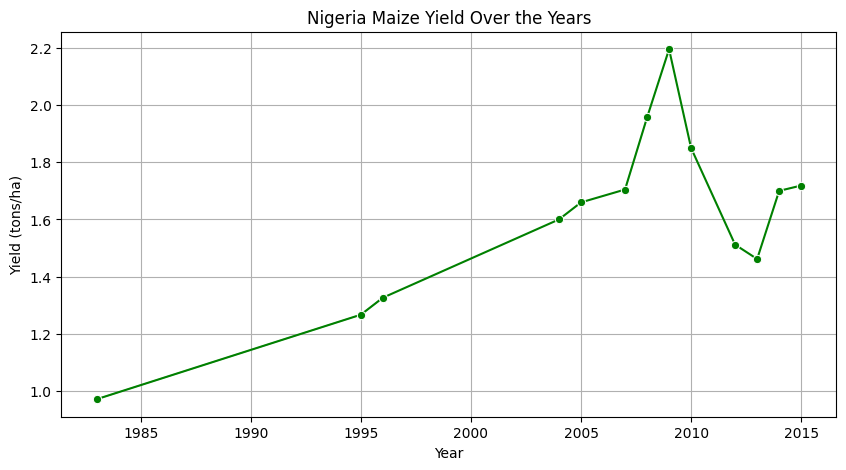

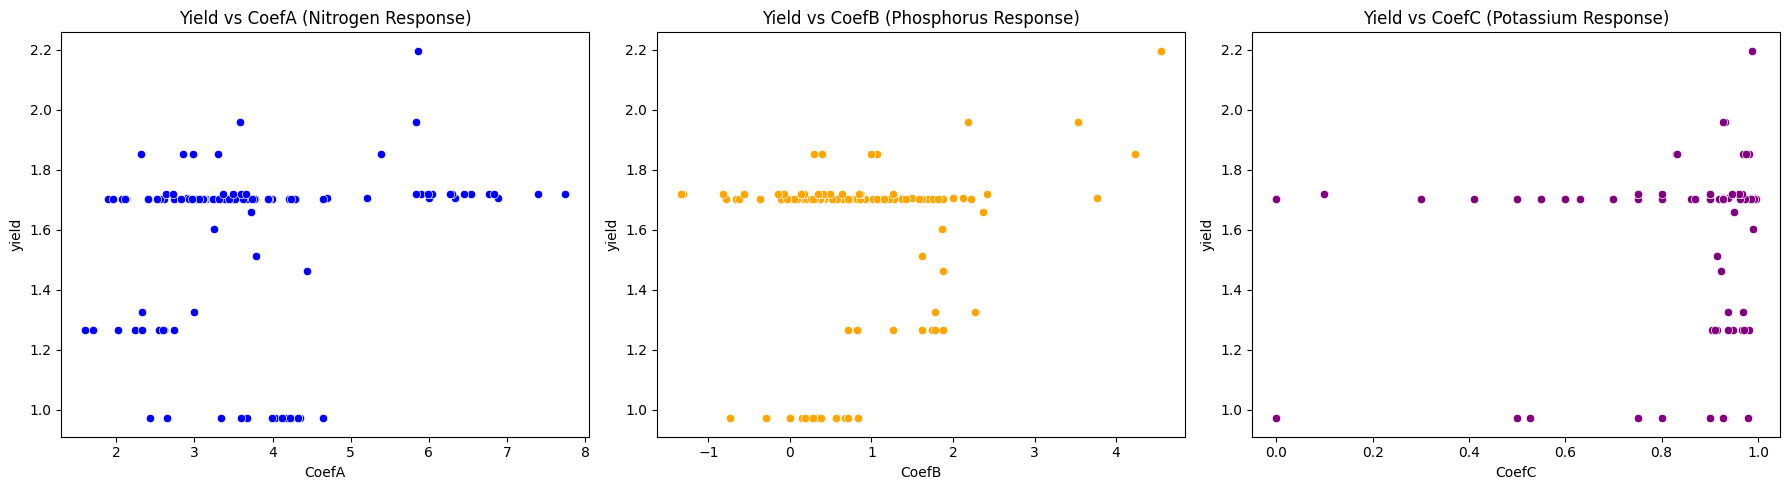


--- Correlation Matrix ---
           yield     CoefA     CoefB     CoefC
yield  1.000000  0.103785  0.155835 -0.031188
CoefA  0.103785  1.000000  0.205118  0.087868
CoefB  0.155835  0.205118  1.000000  0.378592
CoefC -0.031188  0.087868  0.378592  1.000000


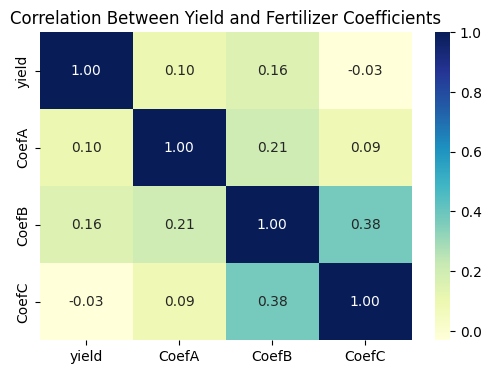

In [ ]:
# ============================
# STEP 1 - Exploratory Data Analysis (EDA)
# ============================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming your merged fertilizer + yield DataFrame is named merged_df
# Example structure check

print("Dataset shape:", merged.shape)
print("\nColumns:", merged.columns.tolist())
print("\nPreview:\n", merged.head())

# ============================
# 1.1 Dataset summary
# ============================

print("\n--- Dataset Info ---")
print(merged.info())

print("\n--- Missing Values ---")
print(merged.isnull().sum())

# ============================
# 1.2 Descriptive statistics
# ============================

print("\n--- Descriptive Statistics ---")
print(merged[['yield', 'CoefA', 'CoefB', 'CoefC']].describe())

# ============================
# 1.3 Trend Visualization
# ============================

plt.figure(figsize=(10, 5))
sns.lineplot(data=merged, x='year', y='yield', marker='o', color='green')
plt.title('Nigeria Maize Yield Over the Years')
plt.xlabel('Year')
plt.ylabel('Yield (tons/ha)')
plt.grid(True)
plt.show()

# Scatter plots for yield vs fertilizer coefficients

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(ax=axes[0], data=merged, x='CoefA', y='yield', color='blue')
axes[0].set_title('Yield vs CoefA (Nitrogen Response)')

sns.scatterplot(ax=axes[1], data=merged, x='CoefB', y='yield', color='orange')
axes[1].set_title('Yield vs CoefB (Phosphorus Response)')

sns.scatterplot(ax=axes[2], data=merged, x='CoefC', y='yield', color='purple')
axes[2].set_title('Yield vs CoefC (Potassium Response)')

plt.tight_layout()
plt.show()

# ============================
# 1.4 Correlation Analysis
# ============================

corr = merged[['yield', 'CoefA', 'CoefB', 'CoefC']].corr()
print("\n--- Correlation Matrix ---\n", corr)

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Correlation Between Yield and Fertilizer Coefficients')
plt.show()

# ============================
# 1.5 Observations Summary (Textual Insight)
# ============================
# After running the above, check printed stats and plots.
# Use these guidelines below for interpretation:
# - If yield increases with higher CoefA/B/C values: fertilizer has a strong positive effect.
# - A low or negative correlation indicates minimal or inverse fertilizer effect.
# - Look at yield trend: if yield increases steadily across years, that shows progress in agricultural productivity

Random Forest Performance:
 MAE: 0.1441
 RMSE: 0.2012
 R²: 0.5651
----------------------------------------
Linear Regression Performance:
 MAE: 0.2509
 RMSE: 0.3007
 R²: 0.0289
----------------------------------------


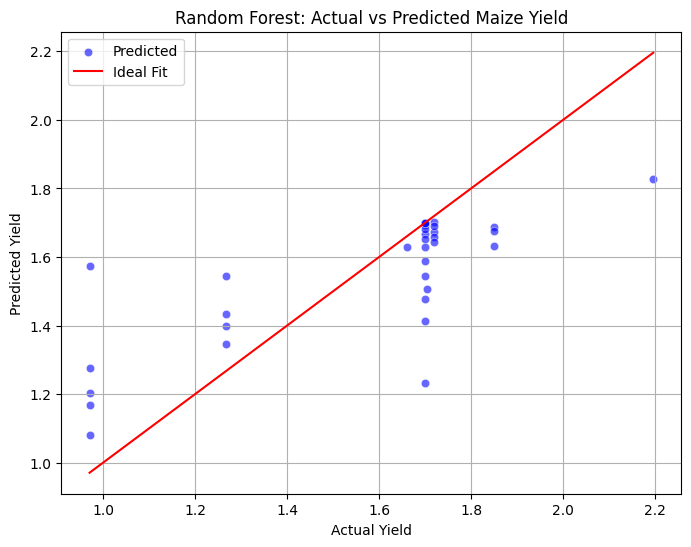

In [ ]:
# Fertilizer–Yield Machine Learning Model for Nigeria

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Load merged fertilizer-yield data
# If already in memory, skip loading. Otherwise, reload your merged DataFrame.
# Example:
# df = pd.read_csv("fertilizer_yield_nigeria.csv")
# For continuity, reuse variable from previous notebook cell:

df = merged.copy()

# 2. Data Cleaning

df = df.dropna(subset=["yield", "CoefA", "CoefB", "CoefC"])
X = df[["CoefA", "CoefB", "CoefC"]]
y = df["yield"]

# 3. Split Data

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# 4. Train Models

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

lr = LinearRegression()
lr.fit(X_train, y_train)

# 5. Predictions

rf_preds = rf.predict(X_test)
lr_preds = lr.predict(X_test)

# 6. Evaluation

def evaluate(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{model_name} Performance:")
    print(f" MAE: {mae:.4f}")
    print(f" RMSE: {rmse:.4f}")
    print(f" R²: {r2:.4f}")
    print("-"*40)

evaluate("Random Forest", y_test, rf_preds)
evaluate("Linear Regression", y_test, lr_preds)

# 7. Visualization

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=rf_preds, color="blue", alpha=0.6, label="Predicted")
sns.lineplot(x=y_test, y=y_test, color="red", label="Ideal Fit")
plt.title("Random Forest: Actual vs Predicted Maize Yield")
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)


,0
CoefA,0.597176
CoefB,0.279148
CoefC,0.123676


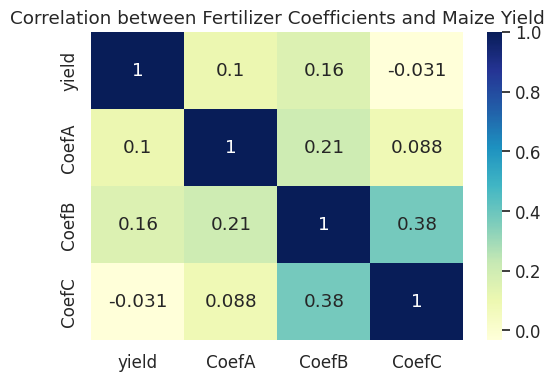

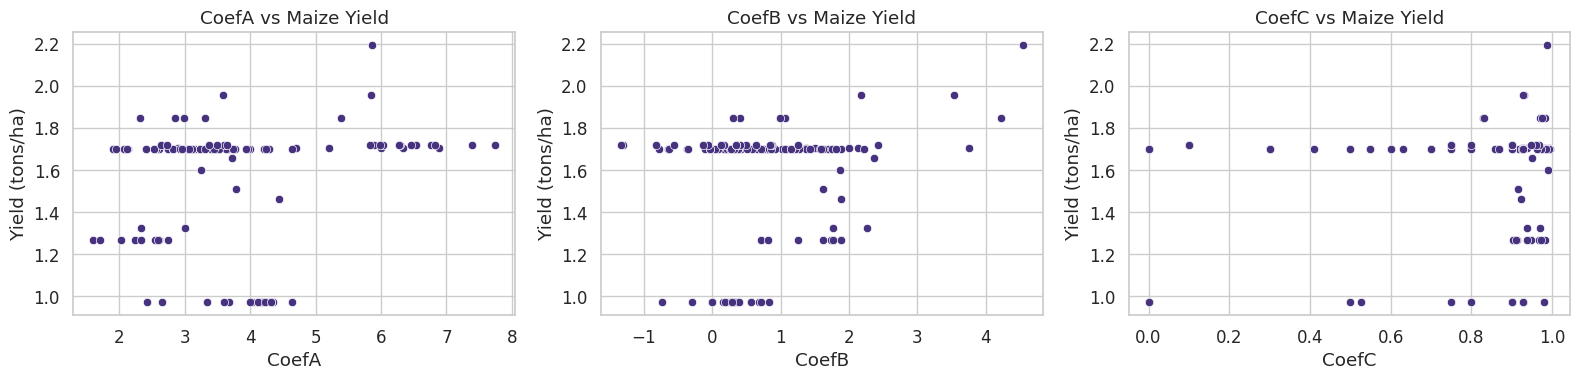

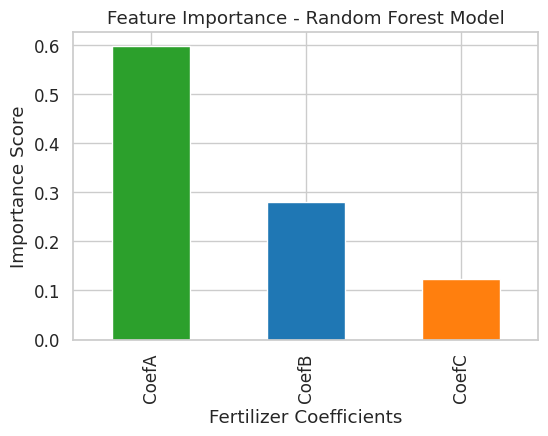

In [ ]:
# Fertilizer-Yield Insight Visualization

import matplotlib.pyplot as plt
import seaborn as sns

# Set style

sns.set(style="whitegrid", palette="viridis", font_scale=1.1)

# 1️⃣ Correlation heatmap

plt.figure(figsize=(6,4))
sns.heatmap(merged[['yield','CoefA','CoefB','CoefC']].corr(), annot=True, cmap='YlGnBu')
plt.title('Correlation between Fertilizer Coefficients and Maize Yield')
plt.show()

# 2️⃣ Scatter plots to visualize linear & nonlinear patterns

fig, axes = plt.subplots(1,3, figsize=(16,4))
for i, coef in enumerate(['CoefA','CoefB','CoefC']):
    sns.scatterplot(x=merged[coef], y=merged['yield'], ax=axes[i])
    axes[i].set_title(f'{coef} vs Maize Yield')
    axes[i].set_xlabel(coef)
    axes[i].set_ylabel('Yield (tons/ha)')
plt.tight_layout()
plt.show()

# 3️⃣ Feature importance bar plot (from previous RandomForest)

# Assuming 'feature_importance' is a pandas Series containing feature importances from the trained RandomForest model
# You can get this from the trained model, e.g., rf.feature_importances_

# If you ran the previous cell, you can get feature importance like this:
feature_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)


feature_importance.plot(kind='bar', color=['#2ca02c','#1f77b4','#ff7f0e'], figsize=(6,4))
plt.title('Feature Importance - Random Forest Model')
plt.ylabel('Importance Score')
plt.xlabel('Fertilizer Coefficients')
plt.show()